In [2]:
# Load data
from pathlib import Path
import pandas as pd

CANDIDATE_DATA_DIRS = [Path('.'), Path('data')]
DATA_DIR = next((p for p in CANDIDATE_DATA_DIRS if (p / 'sample.csv').exists()), Path('.'))
SAMPLE_PATH = DATA_DIR / 'sample.csv'
OUTPUT_DIR = DATA_DIR / 'eda_outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

data = pd.read_csv(SAMPLE_PATH)
print(f'Loaded: {SAMPLE_PATH} | shape={data.shape}')
data.head(10)


Loaded: sample.csv | shape=(222275, 11)


,datetime,delta_time,destination_lat,destination_lng,destination_name,destination_stationId,hour,lat,lng,stationId,stationName
0,1767241726,296.643066,10.844618,106.617803,Cầu vượt An Sương,2179.0,4,10.843738,106.613373,156,Bến xe An Sương
1,1767242023,316.972055,10.858953,106.644233,Cây xăng Năng lượng,2497.0,4,10.844618,106.617803,2179,Cầu vượt An Sương
2,1767242340,982.625612,10.863315,106.720451,Ngã 4 Bình Phước,2199.0,4,10.858953,106.644233,2497,Cây xăng Năng lượng
3,1767243322,105.903015,10.866890,106.727425,Ngã ba mũi tàu đường Gò Dưa,296.0,4,10.863315,106.720451,2199,Ngã 4 Bình Phước
4,1767243428,63.697630,10.868310,106.730198,Chợ Đầu Mối,303.0,4,10.866890,106.727425,296,Ngã ba mũi tàu đường Gò Dưa
5,1767243492,571.092093,10.871597,106.769643,Vietcombank,1935.0,4,10.868310,106.730198,303,Chợ Đầu Mối
6,1767244063,2537.460949,10.874479,106.807659,Bến xe buýt Khu A - Đại học Quốc gia TP.HCM,51573.0,5,10.871597,106.769643,1935,Vietcombank
7,1767246600,276.669377,10.866050,106.801116,Khu DL Suối Tiên,555.0,5,10.874479,106.807659,51573,Bến xe buýt Khu A - Đại học Quốc gia TP.HCM
8,1767246877,178.524739,10.867404,106.787265,ĐH Nông Lâm,1046.0,5,10.866050,106.801116,555,Khu DL Suối Tiên
9,1767247056,338.949393,10.874474,106.762095,Cầu vượt Linh Xuân,321.0,5,10.867404,106.787265,1046,ĐH Nông Lâm


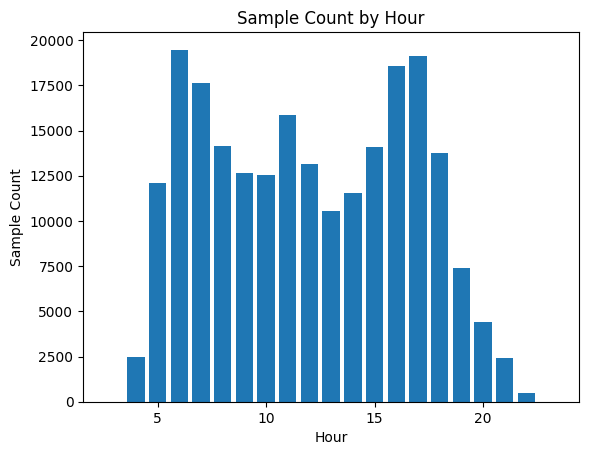

In [3]:
# sample count by `hour` visualization
import matplotlib
if 'get_ipython' not in globals():
    matplotlib.use('Agg')
import matplotlib.pyplot as plt

hour_counts = data['hour'].value_counts().sort_index()
plt.bar(hour_counts.index, hour_counts.values)
plt.xlabel('Hour')
plt.ylabel('Sample Count')
plt.title('Sample Count by Hour')
plt.show()


In [4]:
#convert UNix timestamp to datetime (UTC +7)
dt = data.copy()
dt['datetime'] = pd.to_datetime(dt['datetime'], unit='s')

#from datetime extract hour, day of week, month, minute
dt['day_of_week'] = dt['datetime'].dt.dayofweek
dt['minute'] = dt['datetime'].dt.minute

dt.head(5)

,datetime,delta_time,destination_lat,destination_lng,destination_name,destination_stationId,hour,lat,lng,stationId,stationName,day_of_week,minute
0,2026-01-01 04:28:46,296.643066,10.844618,106.617803,Cầu vượt An Sương,2179.0,4,10.843738,106.613373,156,Bến xe An Sương,3,28
1,2026-01-01 04:33:43,316.972055,10.858953,106.644233,Cây xăng Năng lượng,2497.0,4,10.844618,106.617803,2179,Cầu vượt An Sương,3,33
2,2026-01-01 04:39:00,982.625612,10.863315,106.720451,Ngã 4 Bình Phước,2199.0,4,10.858953,106.644233,2497,Cây xăng Năng lượng,3,39
3,2026-01-01 04:55:22,105.903015,10.866890,106.727425,Ngã ba mũi tàu đường Gò Dưa,296.0,4,10.863315,106.720451,2199,Ngã 4 Bình Phước,3,55
4,2026-01-01 04:57:08,63.697630,10.868310,106.730198,Chợ Đầu Mối,303.0,4,10.866890,106.727425,296,Ngã ba mũi tàu đường Gò Dưa,3,57


In [5]:
#Cyclic encoding for hour and minute
import numpy as np

dt['hour_sin'] = np.sin(2 * np.pi * dt['hour'] / 24)
dt['hour_cos'] = np.cos(2 * np.pi * dt['hour'] / 24)
dt['minute_sin'] = np.sin(2 * np.pi * dt['minute'] / 60)
dt['minute_cos'] = np.cos(2 * np.pi * dt['minute'] / 60)

dt["rush_hour"] = dt['hour'].apply(lambda x: 1 if (x >= 6 and x <= 9) or (x >= 16 and x <= 19) else 0)
dt["weekend"] = dt['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
display(dt.head(5))
print(dt.info())

,datetime,delta_time,destination_lat,destination_lng,destination_name,destination_stationId,hour,lat,lng,stationId,stationName,day_of_week,minute,hour_sin,hour_cos,minute_sin,minute_cos,rush_hour,weekend
0,2026-01-01 04:28:46,296.643066,10.844618,106.617803,Cầu vượt An Sương,2179.0,4,10.843738,106.613373,156,Bến xe An Sương,3,28,0.866025,0.5,0.207912,-0.978148,0,0
1,2026-01-01 04:33:43,316.972055,10.858953,106.644233,Cây xăng Năng lượng,2497.0,4,10.844618,106.617803,2179,Cầu vượt An Sương,3,33,0.866025,0.5,-0.309017,-0.951057,0,0
2,2026-01-01 04:39:00,982.625612,10.863315,106.720451,Ngã 4 Bình Phước,2199.0,4,10.858953,106.644233,2497,Cây xăng Năng lượng,3,39,0.866025,0.5,-0.809017,-0.587785,0,0
3,2026-01-01 04:55:22,105.903015,10.866890,106.727425,Ngã ba mũi tàu đường Gò Dưa,296.0,4,10.863315,106.720451,2199,Ngã 4 Bình Phước,3,55,0.866025,0.5,-0.500000,0.866025,0,0
4,2026-01-01 04:57:08,63.697630,10.868310,106.730198,Chợ Đầu Mối,303.0,4,10.866890,106.727425,296,Ngã ba mũi tàu đường Gò Dưa,3,57,0.866025,0.5,-0.309017,0.951057,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222275 entries, 0 to 222274
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   datetime               222275 non-null  datetime64[ns]
 1   delta_time             222236 non-null  float64       
 2   destination_lat        222236 non-null  float64       
 3   destination_lng        222236 non-null  float64       
 4   destination_name       222236 non-null  object        
 5   destination_stationId  222236 non-null  float64       
 6   hour                   222275 non-null  int64         
 7   lat                    222275 non-null  float64       
 8   lng                    222275 non-null  float64       
 9   stationId              222275 non-null  int64         
 10  stationName            222275 non-null  object        
 11  day_of_week            222275 non-null  int32         
 12  minute                 222275 non-null  int3

In [6]:
# Segment the data with OD pairs
import numpy as np

# OD pair = origin station/location -> destination station/location.
# `segment_key` keeps the human-readable OD pair, while `segment_id` is a stable integer id
# assigned from the unique OD-pair lookup table.
segment_cols = ['stationId', 'destination_stationId']

samples_with_segments = dt.copy()
samples_with_segments['stationId'] = pd.to_numeric(samples_with_segments['stationId'], errors='coerce').astype('Int64')
samples_with_segments['destination_stationId'] = pd.to_numeric(
    samples_with_segments['destination_stationId'], errors='coerce'
).astype('Int64')

valid_od_mask = samples_with_segments[segment_cols].notna().all(axis=1)

od_pair_segments = (
    samples_with_segments.loc[valid_od_mask, segment_cols]
    .drop_duplicates()
    .sort_values(segment_cols)
    .reset_index(drop=True)
)
od_pair_segments.insert(0, 'segment_id', np.arange(1, len(od_pair_segments) + 1, dtype='int64'))
od_pair_segments['origin_id'] = od_pair_segments['stationId'].astype(str)
od_pair_segments['destination_id'] = od_pair_segments['destination_stationId'].astype(str)
od_pair_segments['od_pair'] = od_pair_segments['origin_id'] + ' -> ' + od_pair_segments['destination_id']

# Add useful per-segment counts/statistics from the raw samples.
segment_stats = (
    samples_with_segments.loc[valid_od_mask]
    .groupby(segment_cols, observed=True)
    .agg(
        sample_count=('datetime', 'size'),
        median_delta_time=('delta_time', 'median'),
        mean_delta_time=('delta_time', 'mean'),
        first_timestamp=('datetime', 'min'),
        last_timestamp=('datetime', 'max'),
    )
    .reset_index()
)

od_pair_segments = od_pair_segments.merge(segment_stats, on=segment_cols, how='left')

samples_with_segments = samples_with_segments.merge(
    od_pair_segments[['segment_id', 'stationId', 'destination_stationId', 'od_pair']],
    on=segment_cols,
    how='left',
)
samples_with_segments['segment_status'] = np.where(valid_od_mask, 'assigned', 'missing_od_pair')

# Nullable integer keeps missing OD rows as <NA> instead of converting segment_id to float.
samples_with_segments['segment_id'] = samples_with_segments['segment_id'].astype('Int64')

# Save outputs for modeling and inspection.
od_pair_segments.to_csv(OUTPUT_DIR / 'od_pair_segments.csv', index=False)
samples_with_segments.to_csv(OUTPUT_DIR / 'sample_with_segments.csv', index=False)

print(f'Unique OD-pair segments: {len(od_pair_segments):,}')
print(f'Samples assigned segment_id: {samples_with_segments["segment_id"].notna().sum():,} / {len(samples_with_segments):,}')
print(f'Missing OD-pair samples: {samples_with_segments["segment_id"].isna().sum():,}')
print(f'Saved lookup: {OUTPUT_DIR / "od_pair_segments.csv"}')
print(f'Saved samples: {OUTPUT_DIR / "sample_with_segments.csv"}')

display(od_pair_segments.head(20))
display(samples_with_segments[['datetime', 'stationId', 'destination_stationId', 'od_pair', 'segment_id', 'segment_status', 'delta_time']].head(20))


Unique OD-pair segments: 3,383
Samples assigned segment_id: 222,236 / 222,275
Missing OD-pair samples: 39
Saved lookup: eda_outputs\od_pair_segments.csv
Saved samples: eda_outputs\sample_with_segments.csv


,segment_id,stationId,destination_stationId,origin_id,destination_id,od_pair,sample_count,median_delta_time,mean_delta_time,first_timestamp,last_timestamp
0,1,156,296,156,296,156 -> 296,33,1908.874162,1893.565464,2026-01-01 11:37:14,2026-03-29 13:54:51
1,2,156,300,156,300,156 -> 300,16,1713.458477,20160.914087,2026-01-20 16:19:18,2026-03-21 20:44:46
2,3,156,302,156,302,156 -> 302,2,2411.442863,2411.442863,2026-02-04 09:27:11,2026-02-07 10:40:05
3,4,156,303,156,303,156 -> 303,30,1753.687590,1829.384622,2026-01-15 18:57:44,2026-03-28 10:06:29
4,5,156,304,156,304,156 -> 304,26,1930.349922,1953.248343,2026-01-01 11:22:32,2026-03-29 14:09:06
5,6,156,305,156,305,156 -> 305,7,2132.889300,6225.583315,2026-01-03 05:43:22,2026-03-21 20:56:08
6,7,156,306,156,306,156 -> 306,13,2145.729377,2201.080413,2026-01-02 14:00:00,2026-03-17 19:06:47
7,8,156,308,156,308,156 -> 308,10,1884.341057,1911.193067,2026-01-03 10:52:02,2026-03-30 21:28:39
8,9,156,309,156,309,156 -> 309,5,2089.036612,2030.781362,2026-01-09 10:36:46,2026-03-30 21:03:09
9,10,156,311,156,311,156 -> 311,5,2323.921038,2387.153317,2026-01-03 10:24:01,2026-02-17 08:44:34


,datetime,stationId,destination_stationId,od_pair,segment_id,segment_status,delta_time
0,2026-01-01 04:28:46,156,2179,156 -> 2179,50,assigned,296.643066
1,2026-01-01 04:33:43,2179,2497,2179 -> 2497,2202,assigned,316.972055
2,2026-01-01 04:39:00,2497,2199,2497 -> 2199,3097,assigned,982.625612
3,2026-01-01 04:55:22,2199,296,2199 -> 296,2901,assigned,105.903015
4,2026-01-01 04:57:08,296,303,296 -> 303,82,assigned,63.697630
5,2026-01-01 04:58:12,303,1935,303 -> 1935,208,assigned,571.092093
6,2026-01-01 05:07:43,1935,51573,1935 -> 51573,1791,assigned,2537.460949
7,2026-01-01 05:50:00,51573,555,51573 -> 555,3317,assigned,276.669377
8,2026-01-01 05:54:37,555,1046,555 -> 1046,910,assigned,178.524739
9,2026-01-01 05:57:36,1046,321,1046 -> 321,1641,assigned,338.949393


In [9]:
#Missing values analysis
missing_values = samples_with_segments.isnull().sum()
missing_values

datetime                  0
delta_time               39
destination_lat          39
destination_lng          39
destination_name         39
destination_stationId    39
hour                      0
lat                       0
lng                       0
stationId                 0
stationName               0
day_of_week               0
minute                    0
hour_sin                  0
hour_cos                  0
minute_sin                0
minute_cos                0
rush_hour                 0
weekend                   0
segment_id               39
od_pair                  39
segment_status            0
dtype: int64

In [13]:
#missing values samples

missing_samples = samples_with_segments[samples_with_segments.isnull().any(axis=1)]
missing_samples

,datetime,delta_time,destination_lat,destination_lng,destination_name,destination_stationId,hour,lat,lng,stationId,...,minute,hour_sin,hour_cos,minute_sin,minute_cos,rush_hour,weekend,segment_id,od_pair,segment_status
6407,2026-03-30 22:08:14,NaN,NaN,NaN,NaN,<NA>,22,10.867404,106.787265,1046,...,8,-0.500000,8.660254e-01,7.431448e-01,6.691306e-01,0,0,<NA>,NaN,missing_od_pair
12582,2026-03-30 21:12:41,NaN,NaN,NaN,NaN,<NA>,21,10.852242,106.630935,2582,...,12,-0.707107,7.071068e-01,9.510565e-01,3.090170e-01,0,0,<NA>,NaN,missing_od_pair
18518,2026-03-30 21:13:52,NaN,NaN,NaN,NaN,<NA>,21,10.861472,106.678078,901,...,13,-0.707107,7.071068e-01,9.781476e-01,2.079117e-01,0,0,<NA>,NaN,missing_od_pair
25351,2026-03-30 21:29:10,NaN,NaN,NaN,NaN,<NA>,21,10.873973,106.762476,309,...,29,-0.707107,7.071068e-01,1.045285e-01,-9.945219e-01,0,0,<NA>,NaN,missing_od_pair
31806,2026-03-30 18:58:02,NaN,NaN,NaN,NaN,<NA>,18,10.868120,106.729158,328,...,58,-1.000000,-1.836970e-16,-2.079117e-01,9.781476e-01,1,0,<NA>,NaN,missing_od_pair
37520,2026-03-30 21:22:29,NaN,NaN,NaN,NaN,<NA>,21,10.870254,106.774932,1989,...,22,-0.707107,7.071068e-01,7.431448e-01,-6.691306e-01,0,0,<NA>,NaN,missing_od_pair
42787,2026-03-30 20:04:31,NaN,NaN,NaN,NaN,<NA>,20,10.868120,106.729158,328,...,4,-0.866025,5.000000e-01,4.067366e-01,9.135455e-01,0,0,<NA>,NaN,missing_od_pair
48910,2026-03-30 19:41:15,NaN,NaN,NaN,NaN,<NA>,19,10.861472,106.678078,901,...,41,-0.965926,2.588190e-01,-9.135455e-01,-4.067366e-01,1,0,<NA>,NaN,missing_od_pair
55103,2026-03-29 19:30:09,NaN,NaN,NaN,NaN,<NA>,19,10.858953,106.644233,2497,...,30,-0.965926,2.588190e-01,5.665539e-16,-1.000000e+00,1,1,<NA>,NaN,missing_od_pair
59560,2026-03-05 14:47:54,NaN,NaN,NaN,NaN,<NA>,14,10.867404,106.787265,1046,...,47,-0.500000,-8.660254e-01,-9.781476e-01,2.079117e-01,0,0,<NA>,NaN,missing_od_pair


In [ ]:
#drop rows with missing

df = samples_with_segments.copy()
df.dropna(inplace=True)


datetime                 0
delta_time               0
destination_lat          0
destination_lng          0
destination_name         0
destination_stationId    0
hour                     0
lat                      0
lng                      0
stationId                0
stationName              0
day_of_week              0
minute                   0
hour_sin                 0
hour_cos                 0
minute_sin               0
minute_cos               0
rush_hour                0
weekend                  0
segment_id               0
od_pair                  0
segment_status           0
dtype: int64

In [ ]:
#haversine calculating and 

import math

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    return R * c

